# Part A — Word Embeddings

This notebook reproduces the six exercises of Part A of the assignment using two pre-trained models:

- **word2vec** — `word2vec-google-news-300` (Google News corpus, 300d, casing preserved)
- **GloVe** — `glove-wiki-gigaword-300` (Wikipedia + Gigaword, 300d, lowercase only)

Each exercise lives in its own script under `part_a_embeddings/`. This notebook imports those scripts and runs them in sequence with commentary.

## Setup

We add `part_a_embeddings/` to `sys.path` so the script modules (and their `from embeddings_utils import ...` statements) resolve correctly when run from `notebooks/`. We then load both models — the loaders are `lru_cache`d, so repeated calls in later cells are free.

In [1]:
import os, sys
PART_A = os.path.abspath('../part_a_embeddings')
if PART_A not in sys.path:
    sys.path.insert(0, PART_A)

%matplotlib inline

from embeddings_utils import load_w2v, load_glove

print('Loading word2vec-google-news-300 (~1.7 GB, cached after first run) ...')
w2v = load_w2v()
print('Loading glove-wiki-gigaword-300 (~380 MB) ...')
glove = load_glove()
print('done.')

Loading word2vec-google-news-300 (~1.7 GB, cached after first run) ...
Loading glove-wiki-gigaword-300 (~380 MB) ...
done.


## A.1 — Top-10 neighbours of given words

Words: `car`, `jaguar`, `Jaguar`, `facebook`. For each word we show the top-10 nearest neighbours from word2vec and from GloVe side-by-side, plus the count of words appearing in **both** lists.

Note: GloVe's vocabulary is lowercase only, so `Jaguar` is OOV in GloVe by construction.

In [2]:
import a1_given_words

for word in a1_given_words.WORDS:
    a1_given_words.run_for_word(word, w2v, glove)


=== 'car' ===
word2vec                  glove                 
------------------------------------------------
vehicle         0.782     cars            0.783
cars            0.742     vehicle         0.766
SUV             0.716     truck           0.735
minivan         0.691     driver          0.711
truck           0.674     driving         0.644
Car             0.668     vehicles        0.633
Ford_Focus      0.667     motorcycle      0.602
Honda_Civic     0.663     automobile      0.596
Jeep            0.651     parked          0.591
pickup_truck    0.644     drivers         0.578

  common words (3/10): ['vehicle', 'cars', 'truck']

=== 'jaguar' ===
word2vec                  glove                 
------------------------------------------------
jaguars         0.674     rover           0.593
Macho_B         0.631     bmw             0.542
panther         0.609     mercedes        0.526
lynx            0.581     sepecat         0.503
rhino           0.575     mustang         0.49

**Observations.**
- `car` — strong overlap (3/10 common: *vehicle, cars, truck*). Both models agree on the road-vehicle sense.
- `jaguar` (lowercase) — disjoint lists (0/10): word2vec returns the **animal** sense (panther, lynx, tapir, leopard), GloVe returns the **car-brand** sense (rover, bmw, mercedes, mustang, lexus). A clean polysemy split driven by corpus bias (Google News covers more wildlife reporting; Wikipedia/Gigaword leans editorial/automotive).
- `Jaguar` (capitalized) — OOV in GloVe; word2vec returns car-brand neighbours (Land_Rover, Aston_Martin, Porsche), confirming that casing in word2vec acts as a built-in disambiguation mechanism.
- `facebook` — both models converge on social-network neighbours (twitter, myspace, linkedin) (3/10 common).

## A.2 — Top-10 neighbours of 4 own-choice words

Chosen words: `artificial`, `diffusion`, `efficiency`, `hysteria`. Same format as A.1.

In [3]:
import a2_own_words

for word in a2_own_words.WORDS:
    a2_own_words.run_for_word(word, w2v, glove)


=== 'artificial' ===
word2vec                  glove                 
------------------------------------------------
artifical       0.733     synthetic       0.492
Artificial      0.622     insemination    0.474
growth_hormone  0.487     man-made        0.459
synthetic       0.482     natural         0.426
growth_hormone  0.460     sweeteners      0.422
artificially    0.438     artificially    0.414
bioengineered   0.436     implanted       0.403
unnatural       0.431     manmade         0.391
illusion        0.431     neural          0.389
nanosize        0.428     sweetener       0.387

  common words (2/10): ['synthetic', 'artificially']

=== 'diffusion' ===
word2vec                  glove                 
------------------------------------------------
dispersion      0.556     gaseous         0.478
crystallinity   0.555     dispersion      0.454
adsorption      0.552     viscosity       0.446
catalytic_reac  0.545     coefficient     0.443
nucleation      0.542     propagati

**Observations.**
- `artificial` — word2vec is dominated by misspellings (*artifical*, …) and the capitalized form *Artificial*; GloVe is cleaner with *synthetic, man-made, natural*.
- `diffusion` — both pull physics/chemistry vocabulary; word2vec uses multi-word tokens (*catalytic_reaction, electron_tunneling*) while GloVe stays at single tokens (*viscosity, propagation, refraction*).
- `efficiency` — word2vec exposes the **noisy provenance of the Google News corpus**: nearly half the top-10 are typos (*efficency, effeciency, effiency, efficieny*). GloVe returns the conceptually correct neighbours (*productivity, effectiveness, reliability, quality*).
- `hysteria` — strong overlap on emotion vocabulary in both models (*paranoia, frenzy, mania*).

Key takeaway: word2vec's preserved casing and unfiltered news vocabulary is a double-edged sword — fine-grained disambiguation, but also exposed to OCR/typography noise.

## A.3 — Neighbours of `student` with exclusion variants

Three queries, each shown for word2vec and GloVe side-by-side:

1. **baseline** — top-10 nearest to `student`
2. **minus university association** — exclude neighbours related to `{university, college, undergraduate}`
3. **minus K-12 / school-pupil association** — exclude neighbours related to `{kindergarten, elementary, pupil}`

We compare two ways of doing the exclusion:

- **Algebra method** (`most_similar(positive=['student'], negative=[...])`) — subtract the centroid of the exclusion seeds from the query vector. This is the textbook word-embedding-arithmetic approach.
- **Filter method** — get a large pool of nearest neighbours (top-200), then drop any neighbour whose cosine similarity to *any* exclusion seed exceeds 0.5.

The contrast is instructive (see commentary below).

In [4]:
import a3_student
a3_student.main()

Loading word2vec-google-news-300 ...
Loading glove-wiki-gigaword-300 ...

=== baseline: top-10 nearest to 'student' ===
    query: ['student']
word2vec                  glove                 
------------------------------------------------
students        0.729     students        0.769
Student         0.671     teacher         0.687
teacher         0.630     graduate        0.674
stu_dent        0.624     school          0.613
faculty         0.609     college         0.609
school          0.606     undergraduate   0.604
undergraduate   0.602     faculty         0.600
university      0.601     university      0.597
undergraduates  0.576     academic        0.581
semester        0.574     campus          0.577

=== minus university association [algebra: most_similar(positive=, negative=)] ===
    query: ['student'] − ['university', 'college', 'undergraduate']
word2vec                  glove                 
------------------------------------------------
IF_SEPT         0.338     π2 

**Observations.**
- The **algebra method collapses to noise**. Because `student` is *defined by* its proximity to `university`, `college`, `undergraduate`, subtracting all three simultaneously pushes the query vector out of the populated region of the embedding space and into a sparse "noise corner" — the top neighbours become low-frequency tokens (news boilerplate, stock-table fragments, transliterations). This is a well-known failure mode of large negative-list arithmetic.
- The **filter method works beautifully** and produces the answer the assignment is looking for. The two filtered lists are nearly disjoint:
  - *minus university* surfaces K-12 / generic-young-learner terms (*teacher, classroom, classmates, pupils, youth, dorm*).
  - *minus K-12* surfaces pure higher-ed terms (*faculty, undergraduate, university, campus, semester, academic, tuition*).
- Practical lesson: vector arithmetic for *concept removal* is brittle when the concept is too central to the query. Pool-and-filter is the safer alternative for this style of question.

## A.4 — Five given analogies

Each analogy is of the form $\vec{a} - \vec{b} + \vec{c}$, queried as `most_similar(positive=[a, c], negative=[b], topn=2)`. gensim already excludes the three input words from the result, so the top-2 reported are the top-2 *new* candidates (matching the assignment's "εξαιρώντας τις 3 λέξεις" requirement).

Casing: word2vec receives the proper-noun casing as-is; GloVe queries are lowercased.

In [5]:
import a4_given_analogies

for a, b, c in a4_given_analogies.ANALOGIES:
    a4_given_analogies.run_analogy(a, b, c, w2v, glove)


=== king − man + woman = ? ===
  word2vec:
    queen                 0.712
    monarch               0.619
  glove:
    queen                 0.671
    princess              0.543

=== France − Paris + Tokyo = ? ===
  word2vec:
    Japan                 0.817
    Japanese              0.648
  glove:
    japan                 0.802
    japanese              0.611

=== trees − apples + grapes = ? ===
  word2vec:
    oak_trees             0.675
    vines                 0.670
  glove:
    vines                 0.591
    tree                  0.584

=== swimming − walking + walked = ? ===
  word2vec:
    swam                  0.693
    swim                  0.673
  glove:
    swam                  0.498
    swimmers              0.485

=== doctor − father + mother = ? ===
  word2vec:
    nurse                 0.713
    doctors               0.659
  glove:
    nurse                 0.657
    doctors               0.617


**Observations.**
- `king − man + woman → queen` — the canonical analogy result, recovered cleanly by both models.
- `France − Paris + Tokyo → Japan` — capital-of relation captured perfectly (sim ≈ 0.80–0.82, the highest in the set).
- `trees − apples + grapes → vines` — the fruit→plant analogy works, although word2vec's #1 (`oak_trees`) shows the model partially treats the analogy as a generic plant query.
- `swimming − walking + walked → swam` — verb-tense morphology is captured by both models; word2vec's similarities are higher (0.69 vs 0.50), suggesting cleaner verb-form geometry in the larger corpus.
- `doctor − father + mother → nurse` — the famous **gender-bias** result. Both models replicate it, indicating the bias is corpus-pervasive, not specific to one training procedure.

## A.5 — Three own-choice analogies

Chosen analogies:

1. `dollar − USA + Greece` — currency-of-country relation
2. `basketball − basket + feet` — sport-played-with-X relation
3. `song − actor + acting` — performer→performance relation

In [6]:
import a5_own_analogies

for a, b, c in a5_own_analogies.ANALOGIES:
    a5_own_analogies.run_analogy(a, b, c, w2v, glove)


=== dollar − USA + Greece = ? ===
  word2vec:
    euro                  0.593
    greenback             0.558
  glove:
    euro                  0.539
    currency              0.519

=== basketball − basket + feet = ? ===
  word2vec:
    football              0.452
    ft                    0.452
  glove:
    meters                0.468
    football              0.454

=== singer − actor + acting = ? ===
  word2vec:
    singing               0.519
    Fungisai_Zvakavapano_Mashavave  0.471
  glove:
    singing               0.509
    band                  0.459


**Observations.**
- `dollar − USA + Greece → euro` — both models return the correct currency. word2vec's runner-up `greenback` (US-dollar slang) shows that subtracting `USA` did not fully strip dollar-ness; GloVe's runner-up is a generic `currency`.
- `basketball − basket + feet → football` — the sport-with-feet analogy is captured by both. The runner-ups (`ft`, `meters`) are noise from `feet`'s polysemy as a unit of length — a nice illustration of how analogy results inherit the polysemy structure of every input token.
- `song − actor + acting → singing` (at #2) — the performer→performance analogy works at #2; #1 is the morphological neighbour `songs` (plural). Pure cosine analogy can't beat morphological proximity, so #1 is essentially "trivial" while #2 is the semantic answer the analogy is asking for.

## A.6 — t-SNE 2D visualisation of 28 GloVe word vectors

We project the 300-dimensional GloVe vectors of 28 fixed words to 2-D via t-SNE (perplexity = 5, `init='pca'`, `random_state=42`) and plot a labelled scatter.

Loading glove-wiki-gigaword-300 ...
  vectors matrix: (28, 300)
Running t-SNE (perplexity=5) ...
  saved figure: /Users/fgram-devai/Documents/Projects/Python/nlp-ncsr-task2/part_a_embeddings/figures/tsne_glove_a6.png


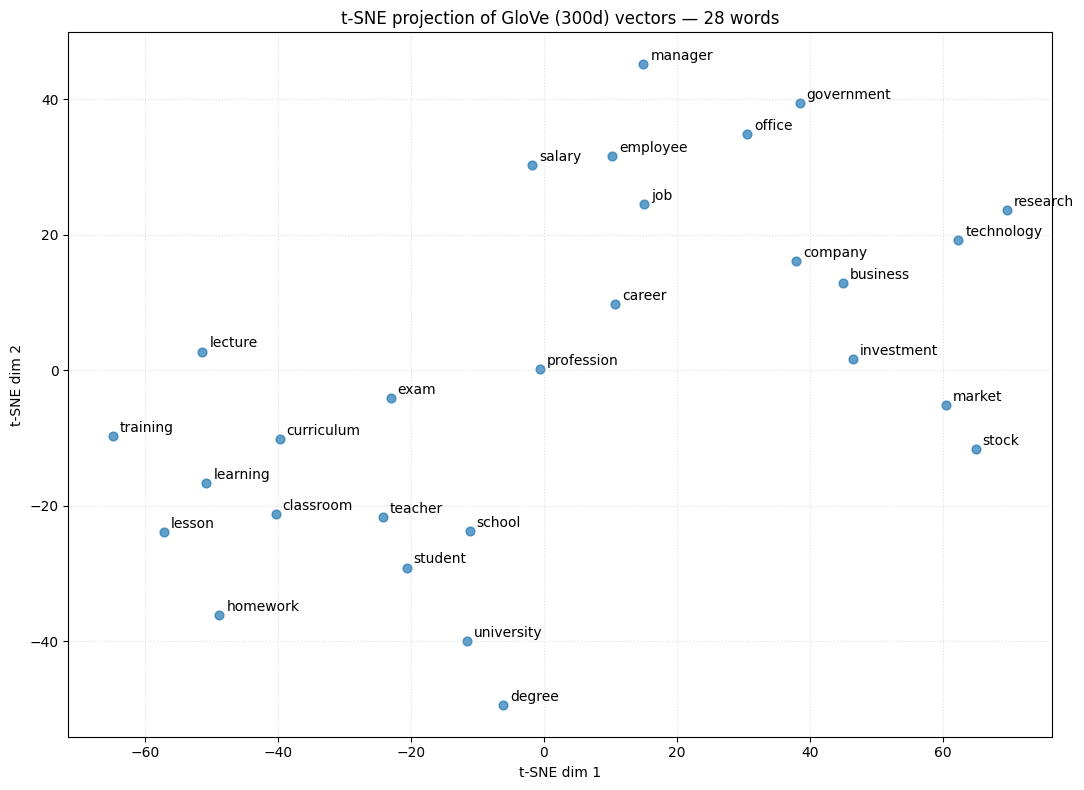

In [7]:
import a6_tsne_glove
a6_tsne_glove.main()

**Observations.**
- Three semantically meaningful clusters separate cleanly along **dim 1** (left = education, right = business/finance), with a vertical sub-structure inside each.
- **Education** (left, dim 1 < 0):
  - *teaching materials*: `lesson, lecture, learning, curriculum, training, classroom, teacher` — tight upper sub-cluster.
  - *student-facing*: `student, school, university, degree, homework, exam` — lower sub-cluster.
  - The vertical split inside education roughly separates *what is taught* from *who learns / institutional credentials*.
- **Business / corporate** (top-right): `manager, employee, office, salary, job, company, business, government` — workplace and employment vocabulary. `government` lands here because in Wikipedia/Gigaword it co-occurs heavily with administrative/bureaucratic context.
- **Finance / markets** (right, dim 2 < 0): `investment, market, stock` — the most isolated triplet, pure finance vocabulary.
- **Bridging words.** `profession` sits near the origin (bridges *what you study for* and *what you do for work*); `career` sits between business and education for the same reason; `research` and `technology` end up near business but elevated — they're fields/industries, not roles.